In [1]:
from scipy.integrate import quad
import matplotlib.pyplot as plt
from main_funcs import *
import numpy as np
import pickle

In [104]:
base_dirs = {
    "Without": Path("data/Without EDM"),
    "With": Path("data/With EDM"),
    "Without New": Path("data/Without EDM NEW"),
    "With New": Path("data/With EDM NEW")
}

data_all = load_array_data(base_dirs)

In [ ]:
def theta_max(lam,gamma=29.303431969091314):
    return np.arcsin(np.sqrt(lam*(1-lam))/(gamma*lam))

In [131]:
N = 10000

theta = data_all["With New"][0]["Y"][:, 0]
lam   = data_all["With New"][0]["X"][0, :]

lambda_curr = 0.45
i_lambda = np.argmin(np.abs(lam - lambda_curr))

w_cma = np.load("C:/Users/JakeS/Documents/Masters Project/mphys-masters-project/Weight_Maps2/optimal_weight_lam=0.45_budget=2040.npz", allow_pickle=True)
w_cma = w_cma["weight"][:,i_lambda]

w0 = w_cma#np.abs(theta*1e-1)#w_cma#np.ones_like(theta)

num_sum = np.zeros_like(theta, dtype=float)
den_sum = np.zeros_like(theta, dtype=float)

for run_id, grids in data_all["With New"].items():
    Zcol = grids["Z"][:, i_lambda]
    p = N * Zcol * 1e-3

    A = np.sum(p * w0)
    B = np.sum(p * w0 * theta)
    C = np.sum(p * w0 * theta**2)
    D = np.sum(p * w0**2)

    y  = B / A
    s2 = C / A - (B / A)**2
    sigma2 = s2 * D / A**2

    Delta = theta - y
    a = Delta - (y * Delta**2)/(2 * s2) + 1.5 * y

    b = (y * A) / D

    weight = (y * p) / sigma2
    num_sum += weight * a
    den_sum += weight * b
    
eps = 1e-30
mask = den_sum > eps

w_opt = np.zeros_like(theta, dtype=float)
w_opt[mask] = num_sum[mask] / den_sum[mask]

w_opt = np.maximum(0.0, w_opt)

In [119]:
print(theta_max(lam[i_lambda])*1e3,abs(theta[np.nanargmax(w_opt)]), (theta_max(lam[i_lambda])*1e3-abs(theta[np.nanargmax(w_opt)]))/(theta_max(lam[i_lambda])))

37.728690194352076 37.27454909819642 12.03702258987097


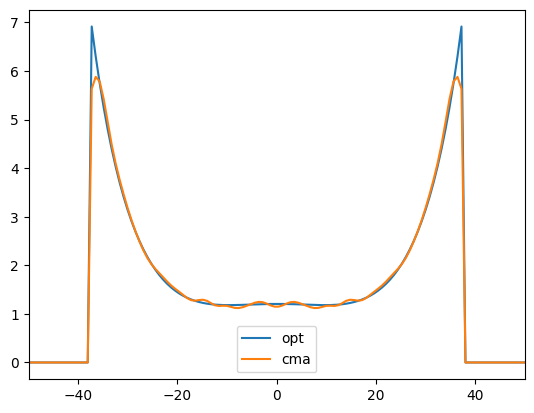

In [132]:
w_cma = np.load("C:/Users/JakeS/Documents/Masters Project/mphys-masters-project/Weight_Maps2/optimal_weight_lam=0.45_budget=2040.npz", allow_pickle=True)

plt.plot(theta,w_opt,label="opt")
plt.plot(theta,w_cma["weight"][:,i_lambda],label="cma")
plt.legend()
plt.xlim([-50,50])
plt.show()

In [116]:
FOM_opt = compute_fom_for_lambda(data_all,N,0.45,weight_func=lambda Y,X: np.tile(w_opt[:, None], (1, X.shape[1])))
FOM_cma = compute_fom_for_lambda(data_all,N,0.45,weight_func=lambda Y,X: w_cma["weight"])
print(FOM_opt['FOM']/FOM_cma['FOM'], FOM_cma['FOM']/FOM_cma['FOM'])

1.0022618419909177 1.0
